In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())

Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
penguins = sns.load_dataset('penguins')

print("Shape:", penguins.shape)
print("\nFirst 5 rows:")
penguins.head()

Shape: (344, 7)

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [5]:
print("Summary Statistics:")
penguins.describe()

Summary Statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
print("Missing Values:")
penguins.isnull().sum()

Missing Values:


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
penguins_clean = penguins.dropna()
print(f"Shape after dropping NA: {penguins_clean.shape}")

Shape after dropping NA: (333, 7)


/tmp/ipykernel_331/400274002.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=penguins_clean, x='species', y='body_mass_g',
/tmp/ipykernel_331/400274002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=penguins_clean, x='species', y='body_mass_g',
/tmp/ipykernel_331/400274002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y='body_mass_g',


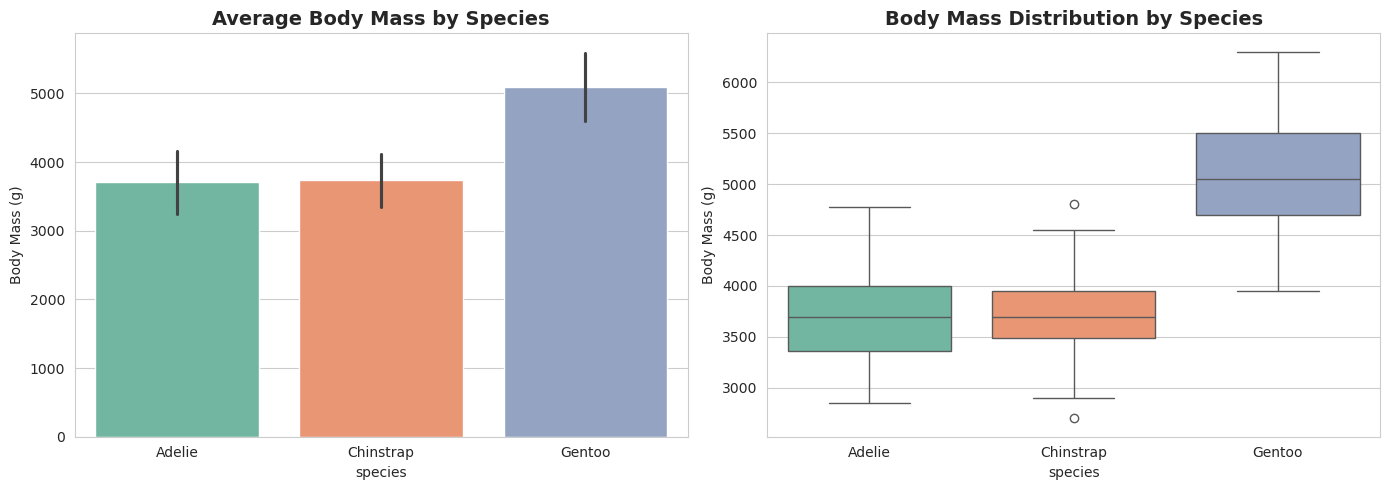

Average Body Mass by Species:
species
Adelie       3706.16
Chinstrap    3733.09
Gentoo       5092.44
Name: body_mass_g, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=penguins_clean, x='species', y='body_mass_g',
            palette='Set2', ax=axes[0], ci='sd')
axes[0].set_title('Average Body Mass by Species', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Body Mass (g)')

sns.boxplot(data=penguins_clean, x='species', y='body_mass_g',
            palette='Set2', ax=axes[1])
axes[1].set_title('Body Mass Distribution by Species', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

print("Average Body Mass by Species:")
print(penguins_clean.groupby('species')['body_mass_g'].mean().round(2))

/tmp/ipykernel_331/1995608699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='island', y='flipper_length_mm',
/tmp/ipykernel_331/1995608699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins_clean, x='island', y='flipper_length_mm',


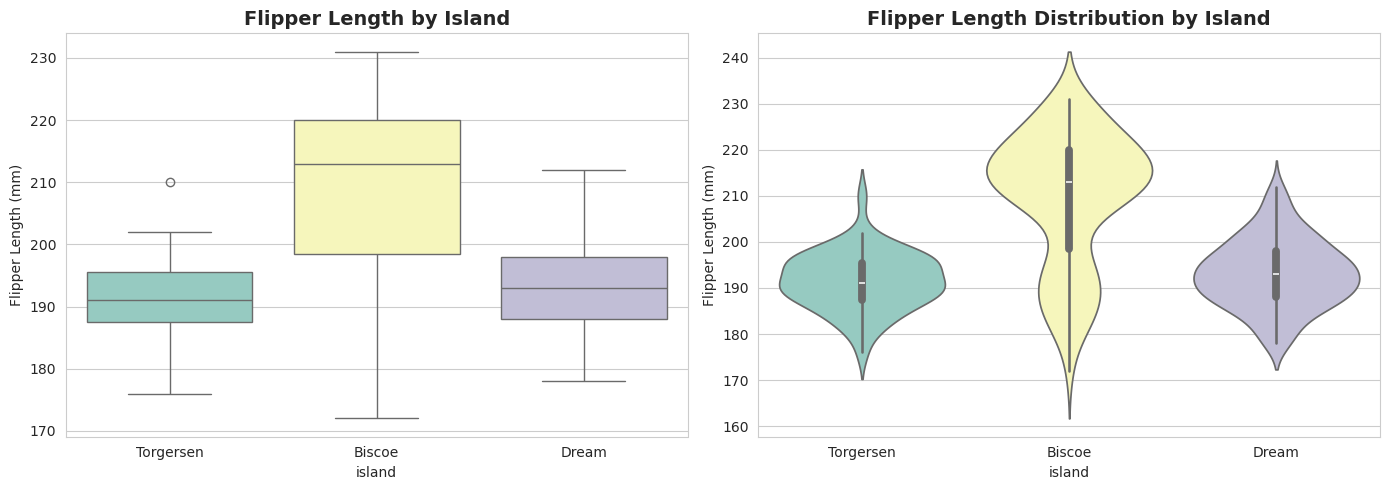

Flipper Length Statistics by Island:
           count    mean    std    min    25%    50%    75%    max
island                                                            
Biscoe     163.0  209.56  14.28  172.0  198.5  213.0  220.0  231.0
Dream      123.0  193.19   7.43  178.0  188.0  193.0  198.0  212.0
Torgersen   47.0  191.53   6.22  176.0  187.5  191.0  195.5  210.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=penguins_clean, x='island', y='flipper_length_mm',
            palette='Set3', ax=axes[0])
axes[0].set_title('Flipper Length by Island', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Flipper Length (mm)')

sns.violinplot(data=penguins_clean, x='island', y='flipper_length_mm',
               palette='Set3', ax=axes[1])
axes[1].set_title('Flipper Length Distribution by Island', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Flipper Length (mm)')

plt.tight_layout()
plt.show()

print("Flipper Length Statistics by Island:")
print(penguins_clean.groupby('island')['flipper_length_mm'].describe().round(2))

In [10]:
print("Species Distribution by Island:")
print(pd.crosstab(penguins_clean['island'], penguins_clean['species']))

Species Distribution by Island:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     119
Dream          55         68       0
Torgersen      47          0       0


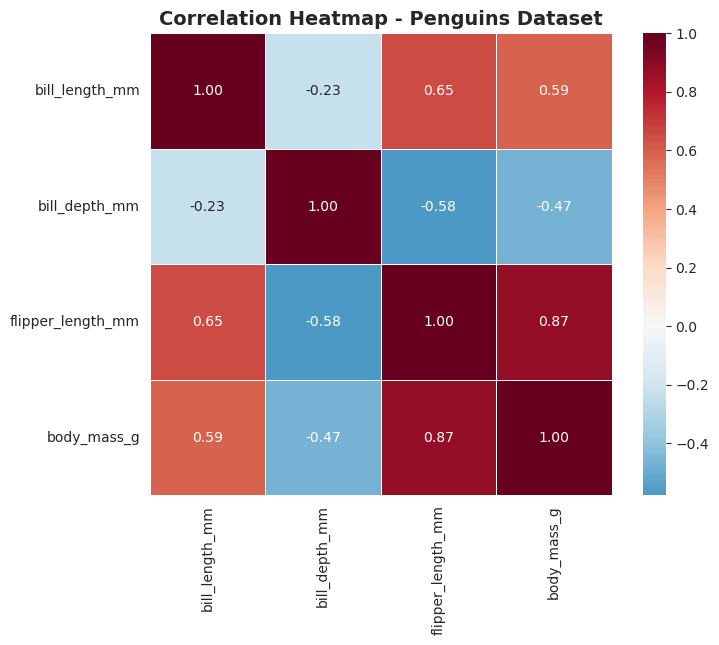

Correlation Matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.229              0.653   
bill_depth_mm              -0.229          1.000             -0.578   
flipper_length_mm           0.653         -0.578              1.000   
body_mass_g                 0.589         -0.472              0.873   

                   body_mass_g  
bill_length_mm           0.589  
bill_depth_mm           -0.472  
flipper_length_mm        0.873  
body_mass_g              1.000  


In [11]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr_matrix = penguins_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Penguins Dataset', fontsize=14, fontweight='bold')
plt.show()

print("Correlation Matrix:")
print(corr_matrix.round(3))

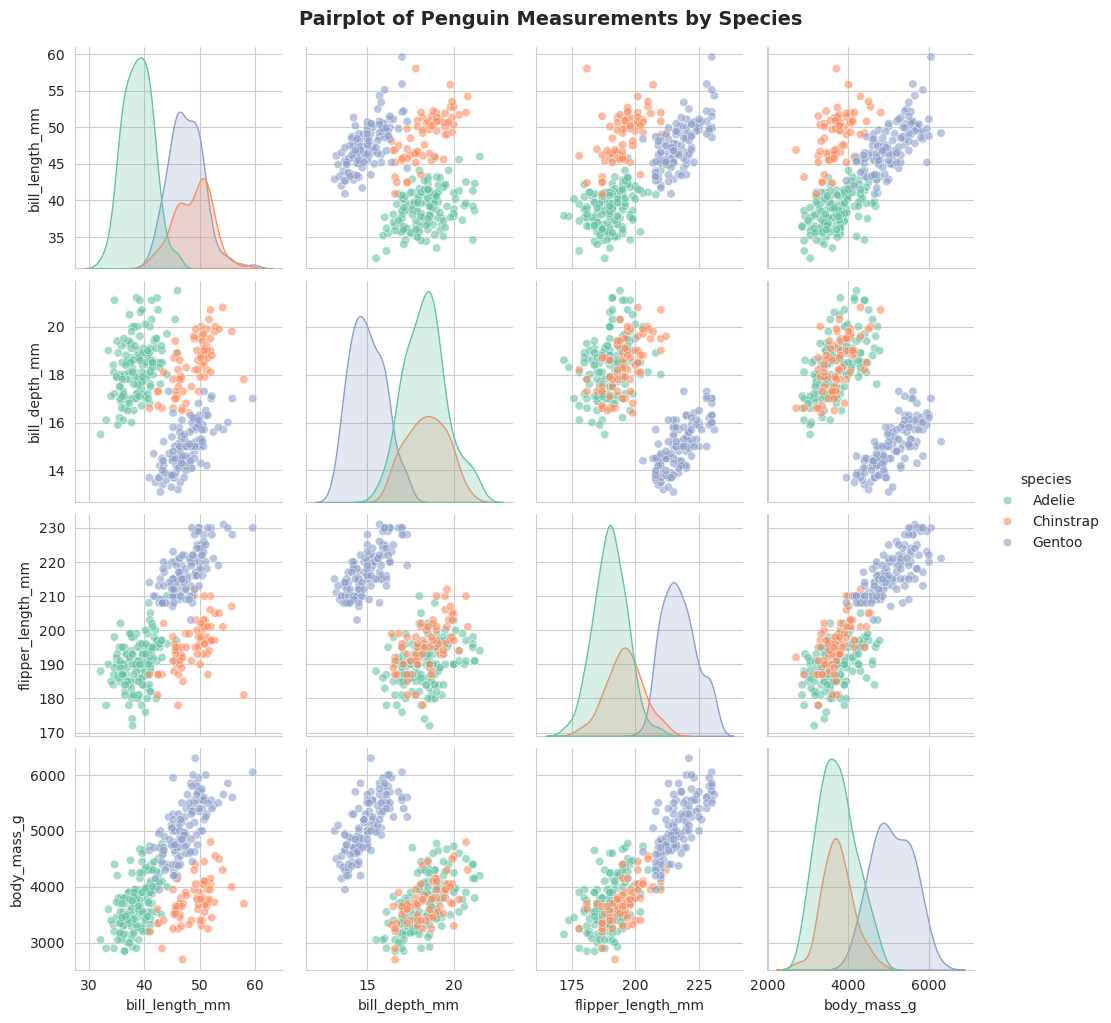

In [13]:
sns.pairplot(penguins_clean, hue='species', palette='Set2',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Penguin Measurements by Species', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()

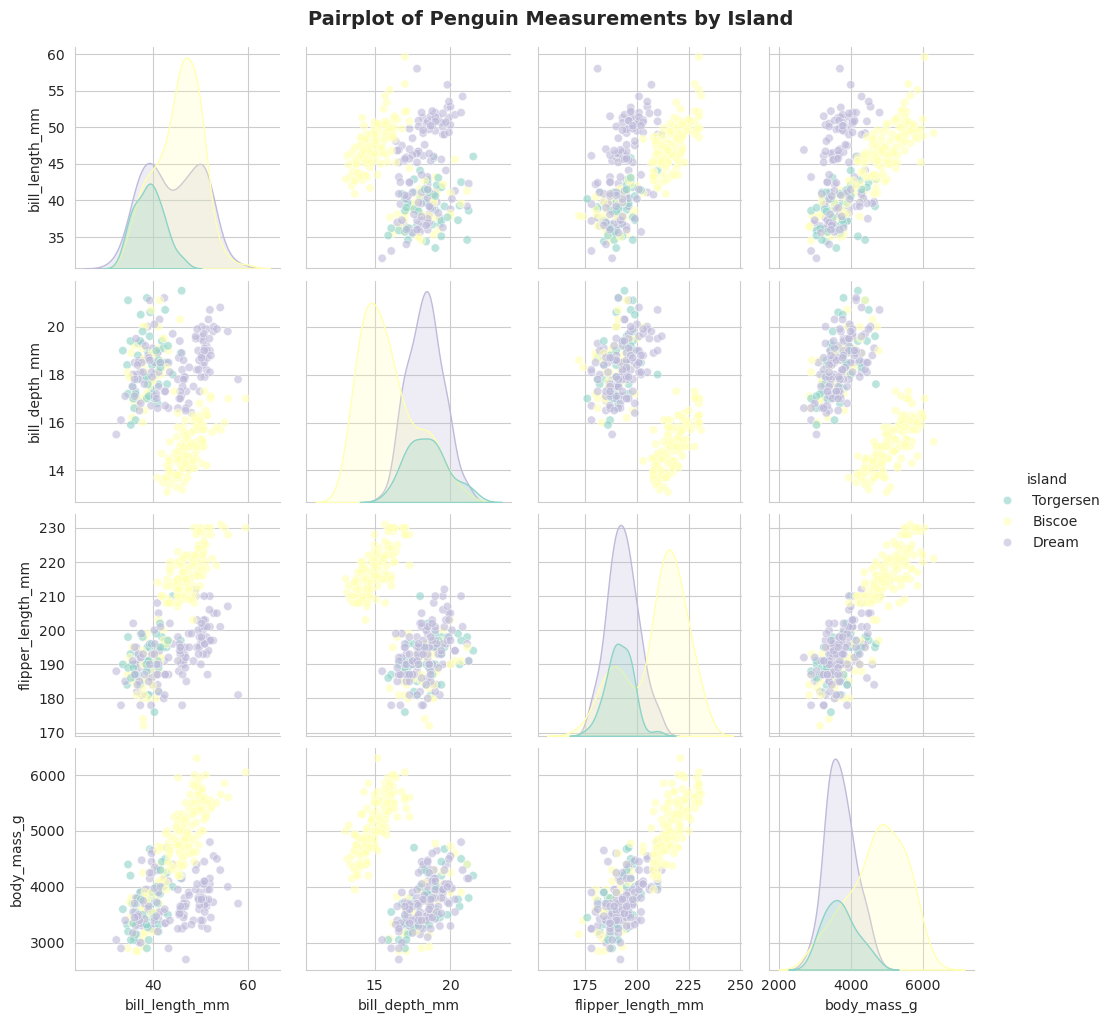

In [14]:
sns.pairplot(penguins_clean, hue='island', palette='Set3',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Penguin Measurements by Island', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()

Average Body Mass by Species (descending):
species
Gentoo       5092.44
Chinstrap    3733.09
Adelie       3706.16
Name: body_mass_g, dtype: float64


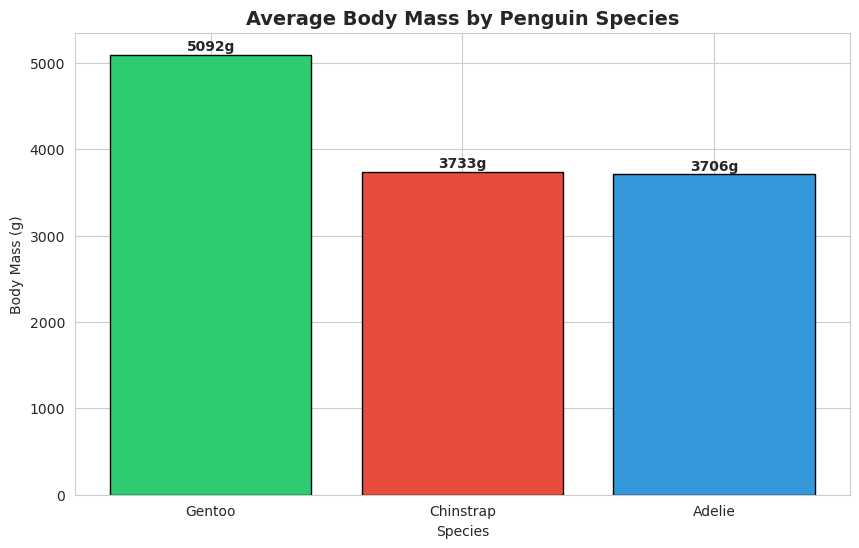

In [15]:
avg_mass = penguins_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)
print("Average Body Mass by Species (descending):")
print(avg_mass.round(2))

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = plt.bar(avg_mass.index, avg_mass.values, color=colors, edgecolor='black')
plt.title('Average Body Mass by Penguin Species', fontsize=14, fontweight='bold')
plt.ylabel('Body Mass (g)')
plt.xlabel('Species')

for bar, value in zip(bars, avg_mass.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{value:.0f}g', ha='center', fontweight='bold')

plt.show()

/tmp/ipykernel_331/1236796512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y=col, palette='Set2', ax=ax)
/tmp/ipykernel_331/1236796512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y=col, palette='Set2', ax=ax)
/tmp/ipykernel_331/1236796512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x='species', y=col, palette='Set2', ax=ax)
/tmp/ipykernel_331/1236796512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

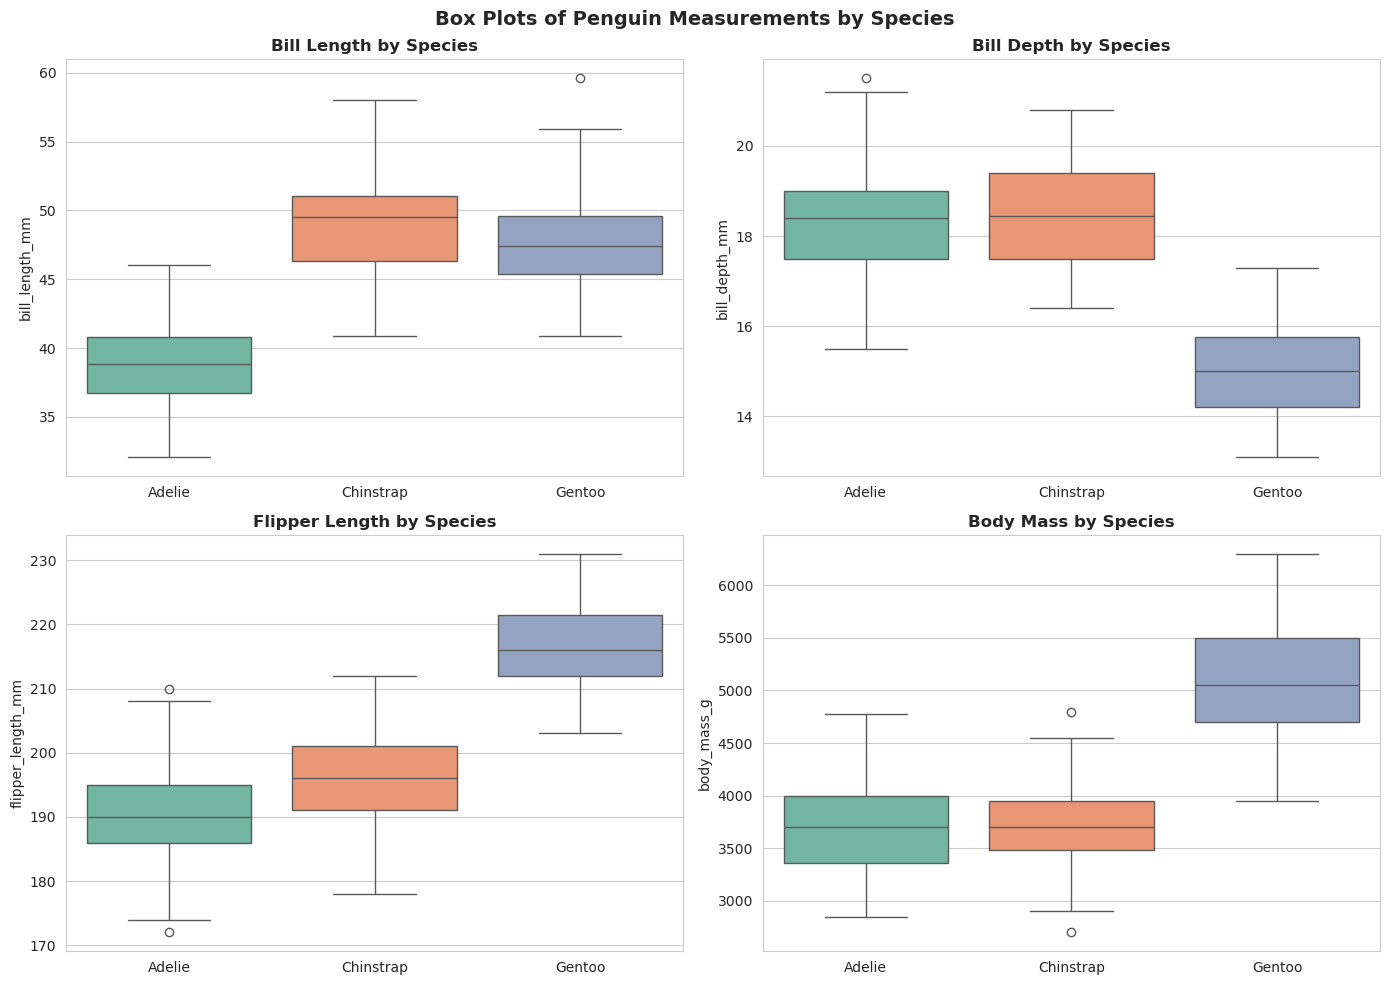

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

measurements = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titles = ['Bill Length', 'Bill Depth', 'Flipper Length', 'Body Mass']

for ax, col, title in zip(axes.flatten(), measurements, titles):
    sns.boxplot(data=penguins_clean, x='species', y=col, palette='Set2', ax=ax)
    ax.set_title(f'{title} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Box Plots of Penguin Measurements by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_331/1228970222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins_clean, x='species', y=col, palette='Set3', ax=ax)
/tmp/ipykernel_331/1228970222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins_clean, x='species', y=col, palette='Set3', ax=ax)
/tmp/ipykernel_331/1228970222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins_clean, x='species', y=col, palette='Set3', ax=ax)
/tmp/ipykernel_331/1228970222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is de

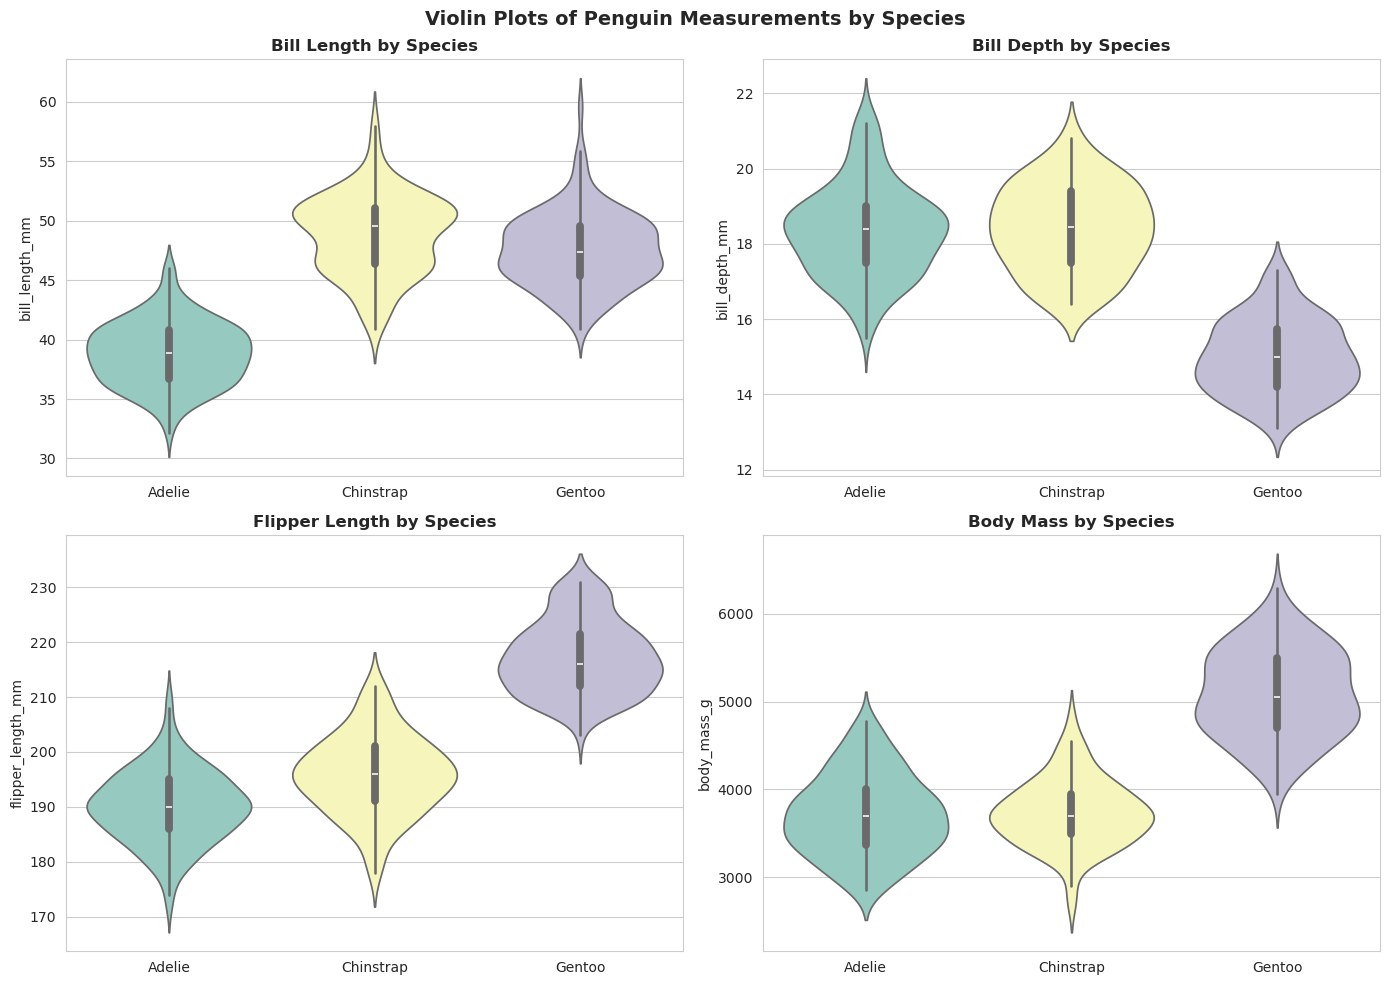

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(axes.flatten(), measurements, titles):
    sns.violinplot(data=penguins_clean, x='species', y=col, palette='Set3', ax=ax)
    ax.set_title(f'{title} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Violin Plots of Penguin Measurements by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()